NAME - VISHAL MARANDI | ROLL NO. - BTECH/10119/21 | DL ASSIGNMENT

In [ ]:
# Required Libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load the data (Q1a)
data = pd.read_csv('/content/temp.csv')
print("Original Data:")
print(data.head())

Original Data:
                        date  temperature_2m  relative_humidity_2m  \
0  2024-10-30 00:00:00+00:00       21.776499                  92.0   
1  2024-10-30 01:00:00+00:00       21.826500                  91.0   
2  2024-10-30 02:00:00+00:00       23.076500                  86.0   
3  2024-10-30 03:00:00+00:00       24.726500                  81.0   
4  2024-10-30 04:00:00+00:00       26.376500                  77.0   

   apparent_temperature  precipitation_probability  precipitation  rain  \
0             25.369894                        5.0            0.0   0.0   
1             25.363144                       15.0            0.0   0.0   
2             26.651030                       13.0            0.0   0.0   
3             28.552795                       13.0            0.0   0.0   
4             30.727776                       28.0            0.0   0.0   

   weather_code  pressure_msl  surface_pressure  cloud_cover  cloud_cover_mid  \
0           1.0        1010.6   

In [ ]:
# Q1(b): Normalize the data using Min-Max scaling
scaler = MinMaxScaler()
temperature_data = data['temperature_2m'].values.reshape(-1, 1)
normalized_temps = scaler.fit_transform(temperature_data)

print("\nNormalized Temperature Data (first 5 values):")
print(normalized_temps[:5])


Normalized Temperature Data (first 5 values):
[[0.38805478]
 [0.3921345 ]
 [0.49412537]
 [0.62875332]
 [0.76338126]]


In [ ]:
# Q1(c): Create sequences for the last three days (72 hours) to predict next day
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 72  # 3 days of hourly data
X, y = create_sequences(normalized_temps, seq_length)

print("\nSequence Shape:", X.shape)
print("Target Shape:", y.shape)


Sequence Shape: (312, 72, 1)
Target Shape: (312, 1)


In [ ]:
# Q1(d): Build LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
print("\nModel Summary:")
model.summary()


Model Summary:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 72, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Q1(e): Train the model
# Reshape input data for LSTM [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

history = model.fit(X, y,
                   epochs=50,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.3183 - val_loss: 0.1674
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.2261 - val_loss: 0.1040
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.1084 - val_loss: 0.1049
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0923 - val_loss: 0.0687
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0891 - val_loss: 0.0681
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0756 - val_loss: 0.0758
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0780 - val_loss: 0.0705
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0666 - val_loss: 0.0687
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0698 - val_loss: 0.0711
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0670 - val_loss: 0.0670
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0677 - val_loss: 0.0697
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0715 - val_loss: 0.0690


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step

Prediction Results:
Predicted next temperature: 19.46°C


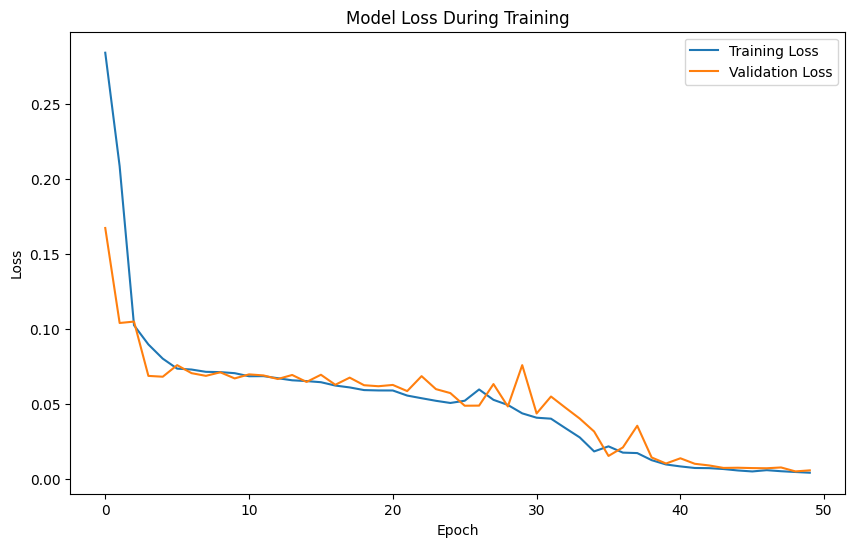

In [ ]:
# Q1(f): Make predictions
# Prepare last sequence for prediction
last_sequence = normalized_temps[-seq_length:]
last_sequence = last_sequence.reshape((1, seq_length, 1))

# Make prediction
predicted_normalized = model.predict(last_sequence)

# Denormalize prediction
predicted_temp = scaler.inverse_transform(predicted_normalized)

print("\nPrediction Results:")
print(f"Predicted next temperature: {predicted_temp[0][0]:.2f}°C")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1505
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1349     
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3323 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0996 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1356 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1225 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1377 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0573 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0725 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0569 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0872 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0462 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0439     
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0649 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0899 
Epoch 16/100
7/7 ━━━━━━━

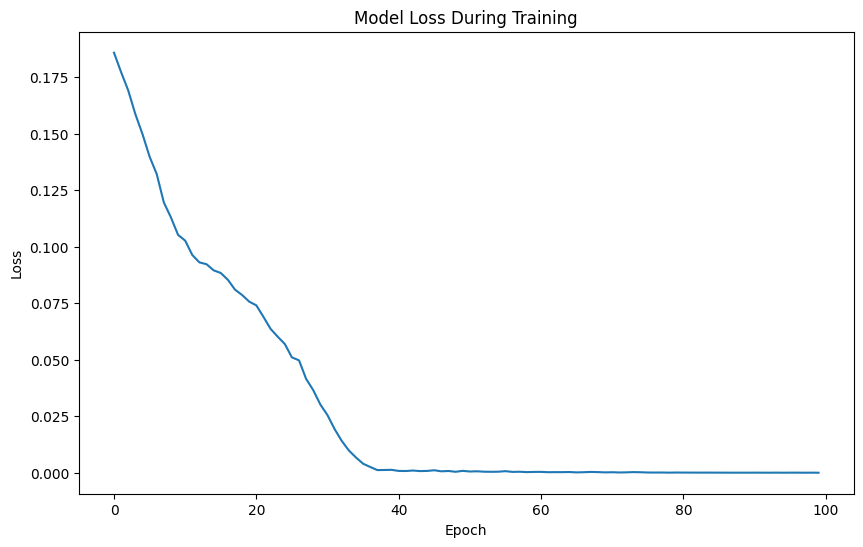

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Define the sequence
sequence = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])

# Normalize the data
scaler = MinMaxScaler()
normalized_sequence = scaler.fit_transform(sequence.reshape(-1, 1))

# Create sequences for training
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 3
X, y = create_sequences(normalized_sequence, seq_length)

# Reshape input to be [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Define the model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Make a prediction
last_sequence = normalized_sequence[-seq_length:]
last_sequence = last_sequence.reshape((1, seq_length, 1))
predicted_normalized = model.predict(last_sequence)

# Denormalize the prediction
predicted = scaler.inverse_transform(predicted_normalized)

print(f"Sequence: {sequence}")
print(f"Predicted next number: {predicted[0][0]:.2f}")

# Plot the training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [2]:
import numpy as np
import tensorflow as tf

# Sample text data (first few lines of "Alice's Adventures in Wonderland")
text = ("Alice was beginning to get very tired of sitting by her sister on the bank, "
        "and of having nothing to do: once or twice she had peeped into the book her sister "
        "was reading, but it had no pictures or conversations in it, 'and what is the use of "
        "a book,' thought Alice, 'without pictures or conversations?'")

# Create a set of unique characters and a mapping from characters to integers
chars = sorted(set(text))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

# Prepare the input and output sequences
sequence_length = 5
X = []
y = []

for i in range(len(text) - sequence_length):
    seq_in = text[i:i + sequence_length]
    seq_out = text[i + sequence_length]
    X.append([char_to_int[char] for char in seq_in])
    y.append(char_to_int[seq_out])

X = np.array(X)
y = np.array(y)


In [3]:
# Reshape the input to be [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Normalize input
X = X / float(len(chars))

# Define the RNN model
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(100, input_shape=(X.shape[1], 1), return_sequences=False),
    tf.keras.layers.Dense(len(chars), activation='softmax')
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
model.fit(X, y, epochs=100, batch_size=32)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0841 - loss: 3.2235    
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1979 - loss: 2.9969  
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1900 - loss: 2.9052 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1912 - loss: 2.8030 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2218 - loss: 2.7649 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1860 - loss: 2.7317 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2022 - loss: 2.7772 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2007 - loss: 2.7453 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1812 - loss: 2.7321 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2121 - loss: 2.6904 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2256 - loss: 2.6391 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [7]:
# Function to predict the next character
def predict_next_char(model, input_seq):
    input_data = np.array([char_to_int[char] for char in input_seq])
    input_data = input_data.reshape((1, len(input_seq), 1)) / float(len(chars))

    prediction = model.predict(input_data, verbose=0)
    index = np.argmax(prediction)

    return int_to_char[index]

# Example prediction
input_sequence = "the book"
next_char = predict_next_char(model, input_sequence)
print(f"The next character after '{input_sequence}' is '{next_char}'")


The next character after 'the book' is 'p'
